Presentation: https://docs.google.com/presentation/d/1ITrVPcM9IZAkGa24iANDzm-Z9j7xl46nPj9qL81zwTQ/edit?usp=sharing

## Section 1 | Challenge Framing

**Name and brief description of your challenge owner (real or hypothetical)**

This project is aimed at providing insights to job seekers, companies, and recruiters interested in understanding the evolving landscape of the AI job market.

**The broader computational experience problem being addressed**

The problem being addressed is the analysis of AI and ML job market trends, specifically focusing on how work modalities (remote, hybrid, in-office) impact compensation following the post-pandemic shift of 2022.

**Why this problem matters in practice? What decision or action should your work support?**

This problem matters in practice because the value and prevalence of remote work have significantly changed since the pandemic. Understanding the association between work modality and compensation can help job seekers make informed career decisions, guide companies in developing competitive compensation strategies, and inform recruiters about market expectations for different roles and work setups. This work will support decisions related to talent acquisition, retention, and career planning within the AI industry.

## Section 2 | Research Questions

**RQ1: An exploratory/descriptive question suited to EDA and unsupervised methods.**

What are the common characteristics and distributions of AI/ML job roles, experience levels, and educational requirements across different countries in the 2025-2026 job market?

**RQ2: A predictive or inferential question suited to supervised modeling.**

Can work modality (remote, hybrid, or in-office) significantly predict the salary range for AI/ML job positions in 2025-2026, after accounting for factors like experience level, education, and country?

## Section 3 | Dataset Plan

**Name:** AI Jobs Market 2025-2026

**Source:** [https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)

**Size:** 1,500 rows x 25 columns

**Time range:** 2025 - 2026

**Key variables and their data types**
* job_id: Categorical
* job_title: Categorical
* job_category: Categorical
* experience_level: Categorical
* years_of_experience: Numerical
* education_required: Categorical
* annual_salary_usd: Numerical
* salary_min_usd: Numerical
* salary_max_usd: Numerical
* city: Categorical
* country: Categorical
* remote_work: Categorical
* company_size: Categorical
* industry: Categorical
* required_skills: Structured Text
* ai_salary_premium_pct: Numerical
* demand_score: Numerical
* demand_growth_yoy_pct: Numerical
* benefits_score_10: Numerical
* posting_year: Categorical
* posting_month: Categorical
* is_senior: Binary
* is_remote_friendly: Binary
* is_llm_role: Binary
* salary_tier: Categorical

**Known data quality issues:** None

**Data triangulation plan if using multiple sources:** N/A

## Section 4 | Pipeline Design

A diagram or structured description of your end-to-end pipeline covering:

**Data ingestion and storage**
*   The `jobs.csv` dataset will be loaded into a pandas DataFrame.
*   The dataset will be stored in memory for analysis.

**Preprocessing and feature engineering steps**
*   **Data Quality Checks and Cleaning:**
    *   **Missing Values:** Identify and quantify missing values across all columns.
    *   **Duplicate Records:** Identify and remove any duplicate rows to ensure data integrity.
    *   **Data Type Conversion:** Verify and convert data types as necessary (e.g., ensure numerical columns are numeric, convert object columns to appropriate categorical types).
    *   **Outlier Detection and Handling:** Identify potential outliers in numerical features (e.g., `annual_salary_usd`, `years_of_experience`) using methods like IQR or Z-score, and decide on a strategy for handling them (e.g., capping, transformation, or removal) if they are likely to skew models.

**Train/validation/test split strategy and rationale**
*   A standard 80/20 train-test split will be applied to the preprocessed data for RQ2. Given the dataset is not time-series and there's no explicit instruction for time-based validation, a random split is appropriate.
*   Stratified sampling will be used if there's a significant class imbalance in the `salary_tier` target variable to ensure representative proportions in both training and testing sets.
*   For RQ1 (unsupervised), no explicit train/test split is needed as clustering is typically performed on the entire dataset.

**Planned unsupervised method(s) for RQ1: K-Means, DBSCAN, Hierarchical Clustering, PCA**
*   **Principal Component Analysis (PCA):** To reduce the dimensionality of the job characteristic features (roles, experience, education, country) and identify underlying patterns or main components that explain the variance, providing a simplified view of the job market structure.
*   **K-Means Clustering:** To identify distinct groups or archetypes of AI/ML job roles based on their characteristics (e.g., combination of job category, experience, education, country). This will help in understanding common job profiles.

**Planned supervised method(s) for RQ2: Naive Bayes, SVM, Decision Tree, Random Forest, or Linear/Logistic Regression**
*   **Random Forest Classifier:** This ensemble method is robust, handles non-linear relationships well, can deal with a mix of numerical and categorical features (after encoding), and provides feature importance, which can help assess the impact of 'remote_work'.
*   **Logistic Regression:** If the problem is framed as predicting specific salary tiers. Logistic Regression provides interpretable coefficients, allowing us to understand the influence of each feature, including `remote_work`, on the likelihood of being in a certain salary tier.

**Evaluation metrics and why they are appropriate for each RQ**
*   **For RQ1 (Unsupervised - PCA & K-Means):**
    *   **PCA:** Explained Variance Ratio (to determine the number of components that capture a significant amount of information) and scree plot visualization.
    *   **K-Means:** Silhouette Score and Davies-Bouldin Index (to evaluate the quality and separation of clusters). Visual inspection of clusters on reduced dimensions (e.g., PCA components).
*   **For RQ2 (Supervised - Random Forest Classifier / Logistic Regression for salary tiers):**
    *   **Accuracy:** Overall correctness of predictions.
    *   **Precision, Recall, F1-Score:** Crucial for evaluating performance across different salary tiers, especially if some tiers are less frequent.
    *   **Confusion Matrix:** To understand the types of errors made (e.g., misclassifying a high-salary job as mid-salary).
    *   **ROC AUC Score:** For binary or multi-class classification, to assess the model's ability to distinguish between classes.

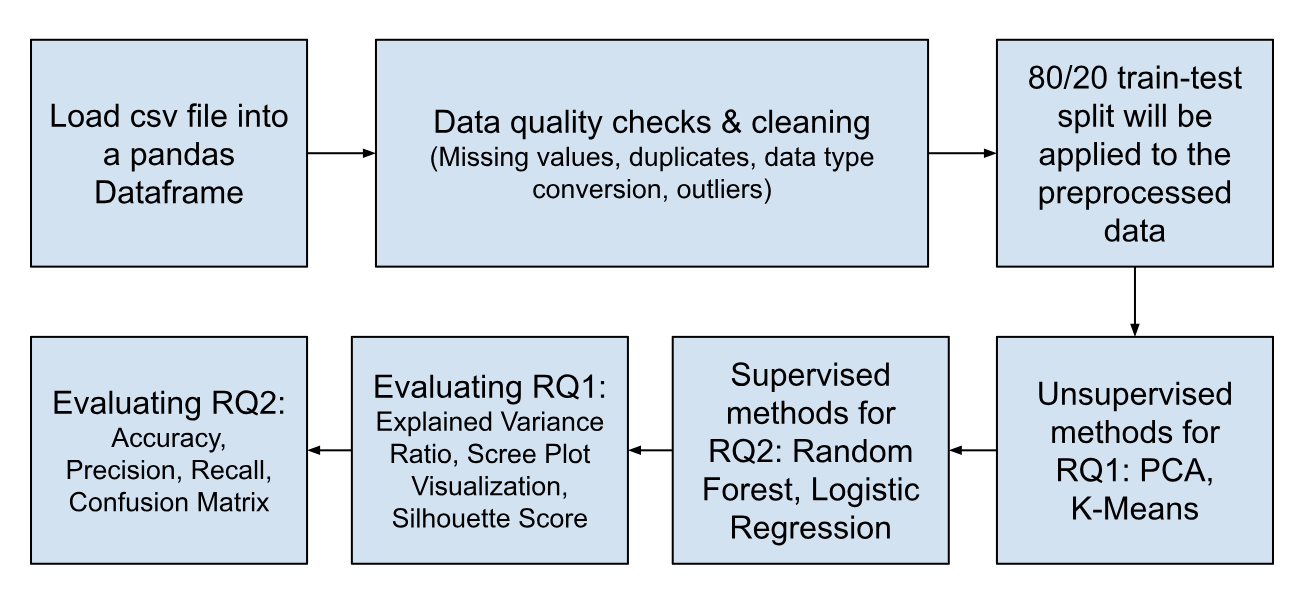

## Section 5 | Stakeholder Communication Plan

**Who is your intended audience?**

My intended audience is people who are considering getting an AI/ML job in the near future. This work will provide insight into the state of the job market. It can also be useful for recruiters.  

**A sketch or wireframe of your planned dashboard or visual report**

The dashboard will be a multi-page interactive web-based report, designed to be intuitive for both job seekers and recruiters. It will feature a clean, modern aesthetic with clear headings and interactive elements (filters, drill-downs).

**Page 1: Executive Summary / Key Trends Overview**
*   **Header:** "AI/ML Job Market Insights: 2025-2026"
*   **Visual 1 (Global Job Market Hotspots):** An interactive map showing the density of AI/ML job postings and average salaries by country and major cities (addressing 'AI/ML Job Market Hotspots'). Users can click on a country to see detailed city-level data.
*   **Visual 2 (Salary Distribution by Work Modality):** A set of violin plots or box plots comparing salary ranges for remote, hybrid, and in-office roles, potentially segmented by experience level (directly addressing RQ2 and 'Remote Work's Salary Premium').
*   **Visual 3 (Top Emerging Skills):** A word cloud or bar chart highlighting the most in-demand new skills (e.g., LLMs, Generative AI) with associated salary premiums (addressing 'Emerging Skill Demand').
*   **Key Findings Panel:** Prominently display the 3-5 'Key Findings' with concise summaries and links to more detailed pages.

**Page 2: Deep Dive: Job Role Characteristics & Experience**
*   **Visual 1 (Job Category Breakdown):** A treemap or stacked bar chart showing the distribution of job categories (e.g., Data Scientist, ML Engineer, AI Researcher) by country and experience level (addressing RQ1).
*   **Visual 2 (Experience vs. Salary & Role):** Scatter plot or grouped bar chart showing average salaries across different experience levels, with a filter to view by job category (addressing 'Experience vs Education').
*   **Visual 3 (Education Requirements):** A bar chart detailing the most common education requirements for various job categories.

**Page 3: Deep Dive: Modality & Compensation (Predictive Insights)**
*   **Visual 1 (Predictive Model Outcome):** A user-friendly interface where users can input desired experience, education, and location to see predicted salary ranges for remote, hybrid, and in-office roles.
*   **Visual 2 (Feature Importance):** A bar chart displaying the feature importance from the predictive model, highlighting how much each factor (especially `remote_work`) contributes to salary prediction.
*   **Visual 3 (Salary Tier Distribution by Modality):** Stacked bar charts showing the proportion of roles falling into different salary tiers (e.g., Entry, Mid, Senior) for remote, hybrid, and in-office positions.

**Overall Layout:** Each page will have a navigation bar. The visuals will be interactive, allowing users to filter by country, job category, experience level, and other relevant features. Tooltips will provide additional detail on hover.

**Immediate Conveyed Insights:** The dashboard should immediately convey which specific skills and locations are currently most lucrative in the AI/ML job market.

**What 3 to 5 "key findings" panels will show if the project succeeds**
*   **AI/ML Job Market Hotspots:** Specific countries and cities exhibit higher concentrations of AI/ML job opportunities, often correlated with innovation hubs and specific industry sectors.
*   **Remote Work's Salary Premium:** Remote AI/ML roles either command a significant salary premium or maintain parity with in-office positions, suggesting a strong candidate preference for flexibility that employers are willing to compensate for.
*   **Emerging Skill Demand:** The rapid evolution of AI technologies (e.g., LLMs, Generative AI) is creating a distinct demand for specialized skills, with roles requiring these skills showing higher average salaries and faster growth.
*   **Experience vs Education:** While foundational education is important, the AI/ML job market heavily prioritizes candidates with 3-5+ years of relevant experience, especially for higher-paying roles.

## Section 6 | Open Questions and Risks

**Open Questions:**
*   How might the rapid evolution of AI technology (e.g., new models, new paradigms) impact the job market predictions for 2025-2026, and how could this be incorporated into future analyses?
*   Are there hidden biases in the data source that could skew findings (e.g., underrepresentation of certain demographics or non-English job markets)?
*   How will global economic shifts or major tech industry events influence the demand for AI/ML roles and salary structures?

**Risks:**
*   **Model Generalizability:** The models developed (especially for RQ2) might not generalize well to unforeseen market dynamics or specific niche AI/ML roles not well-represented in the training data.
*   **Feature Evolution:** The importance or definition of certain features (e.g., 'emerging skills', 'AI salary premium') could change rapidly, making the model's insights less relevant over time.
*   **Ethical Implications:** Misinterpretation or misuse of salary prediction models could lead to unintended consequences, such as reinforcing existing wage disparities or devaluing certain roles.
*   **Scope Limitation:** The project focuses on specific aspects (work modality, experience, education, location). Other crucial factors (e.g., company culture, specific industry sector within AI, job-specific benefits) that influence job seeker decisions and recruiter strategies are not fully captured.